In [ ]:
# pip install lifetimes pandas numpy matplotlib seaborn

# Chuẩn bị dữ liệu giao dịch

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 5000
n_transactions = 30000

data = pd.DataFrame({
    "customer_id": np.random.randint(1, n_customers + 1, n_transactions),
    "date": pd.to_datetime("2025-01-01") + pd.to_timedelta(
        np.random.randint(0, 365, n_transactions), unit="D"
    ),
    "amount": np.random.gamma(shape=2.0, scale=50.0, size=n_transactions)
})

data.head()

,customer_id,date,amount
0,861,2025-01-07,93.756405
1,3773,2025-12-01,32.630012
2,3093,2025-01-03,32.882824
3,467,2025-09-15,169.225678
4,4427,2025-09-20,19.327047


In [ ]:
data.tail()

,customer_id,date,amount
29995,2588,2025-01-08,148.998352
29996,4086,2025-03-15,56.986041
29997,558,2025-11-16,259.460796
29998,4714,2025-05-31,50.243411
29999,4120,2025-04-03,130.750708


In [ ]:
data[data['customer_id'] == 1].sort_values(by="date")

,customer_id,date,amount
26170,1,2025-01-17,67.468364
23996,1,2025-03-10,41.064087
18436,1,2025-08-10,35.460547
15072,1,2025-08-28,140.201976


In [ ]:
from datetime import date

d1 = date(2025, 1, 17)
d2 = date(2025, 8, 28)
delta = d2 - d1

print(f"t_x: {delta.days} days")

d1 = date(2025, 1, 17)
d2 = date(2025, 12, 31)
delta = d2 - d1

print(f"T: {delta.days} days")

t_x: 223 days
T: 348 days


# Tính x, t_x, T cho BG-NBD

In [ ]:
from lifetimes.utils import summary_data_from_transaction_data

summary = summary_data_from_transaction_data(
    data,
    customer_id_col="customer_id",
    datetime_col="date",
    monetary_value_col="amount",
    observation_period_end="2025-12-31"
)

summary.head()


,frequency,recency,T,monetary_value
customer_id,,,,
1,3.0,223.0,348.0,72.242203
2,4.0,210.0,249.0,111.350175
3,5.0,204.0,245.0,90.770118
4,6.0,228.0,253.0,125.268220
5,3.0,214.0,361.0,96.195068


# Huấn luyện mô hình BG-NBD

BG-NBD cho biết khi nào khách quay lại & bao nhiêu lần

In [ ]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    summary["frequency"],
    summary["recency"],
    summary["T"]
)

summary["predicted_purchases_6m"] = bgf.predict(
    180,  # 6 tháng
    summary["frequency"],
    summary["recency"],
    summary["T"]
)


c:\Users\hangh\miniconda3\envs\python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Huấn luyện mô hình Gamma–Gamma

Gamma-Gamma cho biết mỗi lần mua đáng bao nhiêu

In [ ]:
from lifetimes import GammaGammaFitter

ggf = GammaGammaFitter(penalizer_coef=0.01)

summary_gg = summary[summary["monetary_value"] > 0]

ggf.fit(
    summary_gg["frequency"],
    summary_gg["monetary_value"]
)

summary.loc[summary_gg.index, "expected_avg_order_value"] = (
    ggf.conditional_expected_average_profit(
        summary_gg["frequency"],
        summary_gg["monetary_value"]
    )
)


# Tính CLV cho từng khách hàng

CLV = expected purchases × expected order value × margin

In [ ]:
summary["CLV_6m"] = ggf.customer_lifetime_value(
    bgf,
    summary["frequency"],
    summary["recency"],
    summary["T"],
    summary["monetary_value"],
    time=6,               # 6 tháng
    discount_rate=0.01,   # discount rate
    freq="D"
)


c:\Users\hangh\miniconda3\envs\python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Xếp hạng khách hàng theo CLV

In [ ]:
summary = summary.sort_values("CLV_6m", ascending=False)

summary[["frequency", "expected_avg_order_value", "CLV_6m"]].head(10)


,frequency,expected_avg_order_value,CLV_6m
customer_id,,,
1298,1.0,391.747038,906.246649
2030,1.0,301.574093,849.578905
1403,1.0,315.020458,837.856197
4450,1.0,355.122929,789.975776
4664,4.0,213.833708,786.663628
3500,4.0,302.496194,786.614817
2952,7.0,192.496926,758.415191
429,1.0,269.959831,741.698124
4341,8.0,149.259992,723.500984


## Phân vùng High / Medium / Low Future Value

Quantile-based segmentation:

- High Future Value:
    - Ưu tiên retention, VIP program, loyalty, upsell

- Medium Future Value:
    - Cross-sell, nudging campaign, bundle

- Low Future Value:
    - Discount nhẹ, win-back, hoặc giảm ngân sách marketing

In [ ]:
summary["CLV_segment"] = pd.qcut(
    summary["CLV_6m"],
    q=[0, 0.7, 0.9, 1.0],
    labels=["Low Future Value", "Medium Future Value", "High Future Value"]
)

summary["CLV_segment"].value_counts()


CLV_segment
Low Future Value       3438
Medium Future Value     982
High Future Value       492
Name: count, dtype: int64

## Visualization

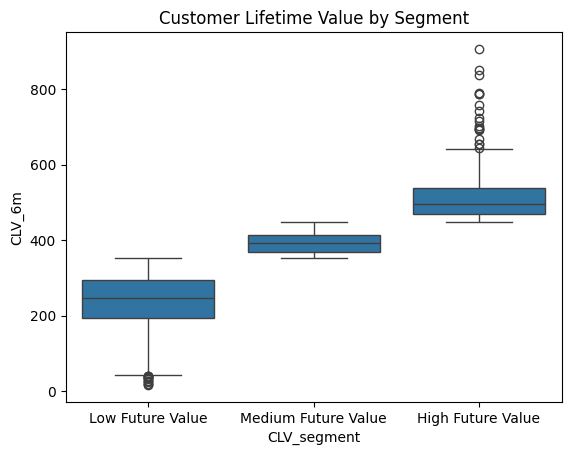

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=summary,
    x="CLV_segment",
    y="CLV_6m"
)
plt.title("Customer Lifetime Value by Segment")
plt.show()
